<center>
    <img src="https://rockborne.com/wp-content/uploads/2021/07/LandingPage-Header-RED-CENTRE.jpg" width="900" alt="logo"  />
</center>

# Deploying CI/CD pipeline in GitHub

To deploy CI/DC on GitHub the following configurations are needed:

- Establish a GitHub repository
- Create Your Workflow File: Create a new directory at the root of your repository called `.github/workflows`. Inside this directory, create a new `YAML` file. The name of this file will be the name of your workflow (e.g., `ml_pipeline.yml`, `model_deploy.yml`). This file is where you define the entire CI/CD process. E.g.,

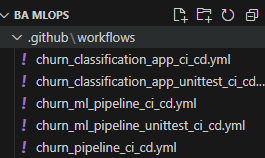

- Define Workflow Triggers (`on`): Within your YAML file, the first thing to configure is when the workflow should run. Example:
    - on: `push`: The workflow runs every time code is pushed to the repository (you can specify branches, e.g., branches: [main]).
    - on: `pull_request`: The workflow runs when a pull request is opened, synchronised, or re-opened.
    - on: `schedule`: You can set it to run at specific intervals, for instance, daily at a certain time to retrain a model.
    - on: `workflow_dispatch`: Allows for manual triggering from the "Actions" tab.

- Define Jobs (`jobs`): Workflows are made up of one or more "jobs." Each job runs on a separate virtual machine (called a "runner"). You'll define distinct jobs for different phases of your pipeline, e.g., `data_preprocessing`, `model_training`, `model_testing`, `model_deployment`. You specify the operating system for the runner, e.g., `runs-on: ubuntu-latest`.

- Define Steps within Jobs (`steps`): Each job consists of a sequence of "steps." These steps are individual tasks that are executed in order. Common Steps for ML CI/CD:

    - Checkout Code: Use the `actions/checkout@v4` Action to get your repository's code onto the runner.

    - Set up Environment: Use `actions/setup-python@v5` to configure the Python version required.

    - Install Dependencies: Run commands like `pip install -r requirements.txt` to install necessary libraries.

    - Run Scripts: Execute your Python scripts for data loading, feature engineering, model training, and evaluation (e.g., `python src/train_model.py`).

    - Run Tests: Execute unit tests, integration tests, and model performance tests (e.g., `pytest`).

    - Build/Push Docker Images: If you're containerising your model.


- Monitor Your Pipeline: Once configured, commit your YAML file to the repository. The workflow will trigger based on your defined `on` events. Go to the "Actions" tab in your GitHub repository. Here, you will see a list of all your workflow runs, their status (success, failure, in progress), and detailed logs for each step. This is your primary dashboard for observing the CI/CD process.

Here below an example of the YAML file for our project.


```
name: Churn Pre-processing Project CI/CD (Unittest)

on:
  push:
    branches: [main]
    paths:
      - '08_01_CI_CD_with_GitHub/**'
  pull_request:
    branches: [main]
    paths:
      - '08_01_CI_CD_with_GitHub/**'

jobs:
  
  test:
    name: Run Unit and Integration Tests
    runs-on: ubuntu-latest

    defaults:
      run:
        working-directory: "08_01_CI_CD_with_GitHub"

    steps:
      - name: Checkout Repository
        uses: actions/checkout@v3

      - name: Set up Python 3.10
        uses: actions/setup-python@v4
        with:
          python-version: '3.10'

      - name: Install Dependencies
        run: |
          python -m pip install --upgrade pip
          pip install -r requirements.txt

      - name: Run Unit Tests
        run: |
          python -m pytest tests/unit -v

      - name: Run Integration Tests
        run: |
          python -m pytest tests/integration -v

```

Here an example of the requirements.txt for this project:

```
# Core Libraries
pandas==2.3.3
numpy==2.2.6
pytest==9.0.2

```

### Pre-Push CI/CD Checklist

Here's a checklist to run through before pushing your changes to the main branch, especially when that push is set to trigger your CI/CD pipeline on GitHub. This helps catch common issues before the automation kicks in.

- [ ] Code Clean: All local changes committed, no temporary or debug code.

- [ ] Tests Pass: All relevant local tests run successfully.

- [ ] Dependencies Current: requirements.txt updated and tested if needed.

- [ ] Documentation Updated: README.md reflects any changes in usage or setup.

- [ ] Workflow Valid: CI/CD workflow files (.yml) are syntactically correct if modified.

- [ ] Clear Commit: Commit message concisely describes the changes.

- [ ] Final Review: Briefly checked all changes and confirming push to main.


After your checklist is complete:

- Prepare Changes: 

    - `git add .` (stages all your modified files)

    - `git commit -m "Your concise commit message"` (saves the changes locally with a note)

- Send to GitHub:

    - `git push origin main` (sends your committed changes to the main branch on GitHub)

- On GitHub, immediately after your push:

    - Your updated code appears in the repository.

    - GitHub Actions detects the change.

    - Your CI/CD workflow automatically starts running.

    - You can watch its progress and results in the "Actions" tab of your GitHub repository.


If no errors are detected... 

__Congratulations, you have deployed an ML CI/CD Process!__

## README.md

Serves as the front door to your project. It should be clear, comprehensive, and easy to navigate, allowing anyone (from a new collaborator to a future self) to quickly understand and engage with your work. `A good README.md` is like a clear project instruction manual and storefront. It should quickly tell you:

- What it is: A brief project summary and its purpose.

- How to set it up: Clear steps to get the code running locally, including dependencies (requirements.txt).

- How to use it: Examples and commands to run the main functionalities.

- What's inside (for ML): Basic info on the data and model, and key results.

- Who made it & how to contribute: Information for collaborators and contact.

- Legal bits: The project's license.

- Essentially, it answers "What is this?", "How do I get it working?", and "How do I use it?".


You can find an example of this file at the end of the notebook. 

# Churn Data Pre-processing Pipeline

This project implements a robust Data Engineering pipeline for processing customer churn data. It handles data extraction, cleaning, feature engineering, and loading, designed with CI/CD best practices using GitHub Actions.

## Features

- **Extraction**: Reads raw data from local CSV files or public URLs.
- **Preprocessing**:
  - **Type Handling**: Converts string columns to numeric where appropriate.
  - **Imputation**: Fills missing values using mean (for numeric) and mode (for categorical).
  - **Feature Engineering**: Creates new features like `MonthlyChargeRatio`.
  - **Target Formatting**: Maps categorical targets (Yes/No) to binary integers (1/0).
- **Loading**: Saves the processed dataset to a specified output directory.
- **Testing**: Comprehensive suite of Unit and Integration tests using `pytest`.
- **CI/CD**: Automated testing workflow via GitHub Actions.

## Project Structure

```text
08_01_CI_CD_with_GitHub/
├── .github/workflows/   # CI/CD configurations
├── src/                 # Source code
│   ├── config.py        # Configuration constants
│   ├── io_handler.py    # Input/Output operations
│   ├── pipeline.py      # Main pipeline orchestration
│   └── preprocessing.py # Data cleaning and transformation logic
├── tests/               # Test suite
│   ├── integration/     # End-to-end integration tests
│   └── unit/            # Unit tests for individual components
├── main.py              # Entry point for the application
├── requirements.txt     # Python dependencies
└── README.md            # Project documentation
```

## Setup & Installation

1. **Clone the repository**:
   ```bash
   git clone <repository-url>
   cd 08_01_CI_CD_with_GitHub
   ```

2. **Set up a virtual environment** (Recommended):
   ```bash
   python -m venv venv
   # Windows
   venv\Scripts\activate
   # macOS/Linux
   source venv/bin/activate
   ```

3. **Install dependencies**:
   ```bash
   pip install -r requirements.txt
   ```

## Usage

To run the full data pipeline manually:

```bash
python main.py
```

This will read the configuration from `src/config.py`, process the raw data, and save the result to the configured output path.

## Testing

This project uses `pytest` for testing.

**Run Unit Tests:**
```bash
pytest tests/unit -v
```

**Run Integration Tests:**
```bash
pytest tests/integration -v
```